In [4]:
from detect_perso import run_detect_perso
import pandas as pd
import torch

In [5]:
directory, detections = run_detect_perso(source='inference/images', weights=['runs/train/yolov7-ag/weights/best.pt'],
                                         conf_thres=0.25, img_size=640, save_csv=False, save_img=True)
print(f"detections{detections}")
print(f"directory{directory}")




YOLOR 🚀 2025-11-28 torch 2.2.2+cu121 CPU



Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse


Model Summary: 328 layers, 37167174 parameters, 6194944 gradients, 104.1 GFLOPS


 Convert model to Traced-model... 
 traced_script_module saved! 
 model is traced! 



Processing images: 100%|██████████| 8/8 [00:21<00:00,  2.69s/it]

Done. (21.532s)
detections[]
directoryruns/detect/exp48


In [6]:
df = pd.DataFrame(detections)
print(df.head())

Empty DataFrame
Columns: []
Index: []


In [7]:
from PIL import Image

#Warning PAth it can change 
PATH = '/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/Data_Projet/mission_herbonaute_2000/'


def crop_detection(df_row, image_path_col='id'):
    image_id = df_row[image_path_col]
    x_min = int(df_row['x_min_pixel'])
    y_min = int(df_row['y_min_pixel'])
    x_max = int(df_row['x_max_pixel'])
    y_max = int(df_row['y_max_pixel'])

    print(x_min, x_max, y_min, y_max)

    image_path = PATH + image_id + ".jpg"

    try:
        original_image = Image.open(image_path)
    except FileNotFoundError:
        print(f"Le fichier image n'a pas été trouvé à : {image_path}")
        return None

    print(f"original image size {original_image.size}")
    cropped_image = original_image.crop((x_min, y_min, x_max, y_max))
    print(image_id)
    return cropped_image

In [8]:
crop_detection(df.iloc[3]).show()

IndexError: single positional indexer is out-of-bounds

In [9]:
def auto_generate_weights(detections_list, grid_size=24):
    unique_ids = list(dict.fromkeys([d['id'] for d in detections_list]))
    batch_weights = []

    # On définit des scores clairs
    scores = {'flower': 3.0, 'leaf': 2.0, 'stem': 1.0}

    for img_id in unique_ids:
        dets = [d for d in detections_list if d['id'] == img_id]
        weights = torch.full((grid_size, grid_size), 0.1)

        # /!\ ÉTAPE CRUCIALE : On doit trouver la taille RÉELLE de l'image
        # pour convertir les pixels en indices de grille proprement.
        # Si YOLO a tourné l'image, ça peut tout décaler.
        img_w = max([d['x_max_pixel'] for d in dets] + [1])
        img_h = max([d['y_max_pixel'] for d in dets] + [1])

        for d in dets:
            score = scores.get(d['class_name'], 1.0)

            # Conversion précise Ratio -> Grille
            # On utilise (grid_size - 1) pour ne pas déborder
            x1 = int((d['x_min_pixel'] / img_w) * (grid_size - 1))
            x2 = int((d['x_max_pixel'] / img_w) * (grid_size - 1)) + 1
            y1 = int((d['y_min_pixel'] / img_h) * (grid_size - 1))
            y2 = int((d['y_max_pixel'] / img_h) * (grid_size - 1)) + 1

            # Sécurité bornes
            x1, x2 = max(0, x1), min(grid_size, x2)
            y1, y2 = max(0, y1), min(grid_size, y2)

            # Remplissage
            if y2 > y1 and x2 > x1:
                # IMPORTANT : Dans imshow et les matrices, l'ordre est [y, x]
                weights[y1:y2, x1:x2] = torch.max(weights[y1:y2, x1:x2], torch.tensor(score))

        # On aplatit (N, 1)
        batch_weights.append(weights.view(-1, 1))

    return torch.stack(batch_weights)

In [10]:
weights_vit = auto_generate_weights(detections, grid_size=24)

print(f"Forme des poids prête pour le ViT : {weights_vit.shape}")

RuntimeError: stack expects a non-empty TensorList

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import torch

# 1. On sélectionne la PREMIÈRE image du batch [0]
image_id_test = detections[0]['id']  # ex: 'AIX034925'
weights_test = weights_vit[0]  # Poids ViT correspondants

# 2. Trouver l'image YOLO sauvegardée (dansruns/detect/exp26)
image_yolo_path = os.path.join(directory, f"{image_id_test}.jpg")

if not os.path.exists(image_yolo_path):
    # Sécurité : Si l'image YOLO n'est pas trouvée, on cherche l'originale
    print(f"Image YOLO non trouvée, on cherche l'originale pour l'ID {image_id_test}")
    # Adapte le chemin ci-dessous vers ton dossier d'images originales
    image_to_show_path = f"inference/images/{image_id_test}.jpg"
else:
    image_to_show_path = image_yolo_path

# 3. Vérification de sécurité avant affichage
if not os.path.exists(image_to_show_path):
    print(f"CRITICAL : Aucune image trouvée pour l'ID {image_id_test}. Vérifie les chemins.")
else:
    # --- Création de la Figure de Superposition ---
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    # A. Afficher l'image de l'herbier (Fond)
    img = mpimg.imread(image_to_show_path)
    ax.imshow(img)
    ax.set_title(f"Superposition Poids/Herbier : {image_id_test}")
    ax.axis('off')  # Cache les axes

    # B. Afficher la grille de poids ViT (Superposée)
    # On remet en 2D (14x14) et on s'assure que c'est sur CPU
    weights_2d = weights_test.view(24, 24).detach().cpu().numpy()

    # cmap='hot' est bien car : noir=0.1 (fond), rouge=1.0 (tige), jaune=2.0+ (feuilles/fleurs)
    # L'argument ALPHA gère l'opacité (0.0 transparent, 1.0 opaque)
    im_weights = ax.imshow(weights_2d,
                           cmap='hot',
                           interpolation='nearest',
                           alpha=0.6,  # Opacité de 60% pour voir l'herbier derrière
                           extent=[0, img.shape[1], img.shape[0], 0])  # Recouvre toute l'image

    # C. Ajouter la Colorbar pour l'échelle d'importance sémantique
    fig.colorbar(im_weights, ax=ax, label="Importance sémantique (Poids patch)")

    # D. Affichage du résultat (directement dans le notebook grâce à %matplotlib inline)
    plt.show()

IndexError: list index out of range

In [12]:
import sys
import os

# On récupère le dossier actuel (où se trouve ton notebook)
current_dir = os.getcwd()

# Si tu es déjà dans YOLOv7_ag, on pointe juste vers 'src'
# Sinon, on pointe vers 'YOLOv7_ag/src'
if current_dir.endswith("YOLOv7_ag"):
    path_to_src = os.path.abspath("src")
else:
    path_to_src = os.path.abspath("YOLOv7_ag/src")

# On nettoie le sys.path des anciennes erreurs pour repartir à zéro
sys.path = [p for p in sys.path if "YOLOv7_ag/YOLOv7_ag" not in p]

# On ajoute le BON chemin en priorité
if path_to_src not in sys.path:
    sys.path.insert(0, path_to_src)

print(f"Le chemin ajouté est : {path_to_src}")

# Test de l'import
from model.dual_crossvit import DualCrossVit

Le chemin ajouté est : /mnt/2210B8B210B88E73/Documents/Ing 3/PFE/YOLOv7_ag/src


/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/.venv/lib/python3.12/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [13]:
import torch
from PIL import Image
from torchvision import transforms

# On suppose que tu as importé tes fonctions et ton modèle
# from detect_perso import run_detect_perso
# from ton_fichier_modele import DualCrossVit
# from ton_fichier_utilitaire import auto_generate_weights

# ---------------------------------------------------------
# 1. Création du modèle
# ---------------------------------------------------------
model = DualCrossVit(
    img_size=(224, 224),
    patch_size=(8, 16),  # La branche Small aura des patchs de 8x8, la Large de 16x16
    num_classes=2
)
model.eval()  # On met le modèle en mode évaluation (très important pour l'inférence)

# ---------------------------------------------------------
# 2. Chargement et préparation de l'image
# ---------------------------------------------------------
# PyTorch a besoin que l'image soit un "Tenseur" (une matrice mathématique)
# et qu'elle soit à la bonne taille (224x224)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# On charge la vraie image
chemin_image = "/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/Data_Projet/mission_herbonaute_2000/AIX055881.jpg"
image_pil = Image.open(chemin_image).convert('RGB')
image_tensor = transform(image_pil)

# Les modèles s'attendent toujours à recevoir un "batch" (un groupe) d'images.
# Même si on a qu'une seule image, on doit ajouter une dimension au début.
# L'image passe de la forme [3, 224, 224] à [1, 3, 224, 224]
image_batch = image_tensor.unsqueeze(0)

# ---------------------------------------------------------
# 3. L'INTERVENTION DE YOLO (Génération de l'attention)
# ---------------------------------------------------------
# Tu passes l'image dans ton modèle YOLO
_, detections = run_detect_perso(
    source=chemin_image,  # On donne le chemin exact de l'image
    weights=['runs/train/yolov7-ag/weights/best.pt'],
    conf_thres=0.25,
    img_size=640,
    save_csv=False,
    save_img=True
)

# Cette fonction regarde où YOLO a vu des fleurs (poids=3) ou des feuilles (poids=2)
# et elle fabrique la grille 14x14 !
poids_reels_yolo = auto_generate_weights(detections, grid_size=14)

# On s'assure que les poids ont aussi la dimension du batch : [1, 196, 1]
if len(poids_reels_yolo.shape) == 2:
    poids_reels_yolo = poids_reels_yolo.unsqueeze(0)

# ---------------------------------------------------------
# 4. Passage dans le DualCrossVit
# ---------------------------------------------------------
# Comme tu gardes le fond, on donne la même image aux deux branches !
# La taille des patchs (8 et 16) fera la différence.
with torch.no_grad():  # On dit à PyTorch de ne pas calculer les gradients (plus rapide)
    predictions = model(
        x_small=image_batch,
        x_large=image_batch,  # On utilise la même image ici
        weights=poids_reels_yolo
    )

print("Taille des prédictions :", predictions.shape)  # Devrait afficher [1, 2]
print("Prédictions brutes :", predictions)



YOLOR 🚀 2025-11-28 torch 2.2.2+cu121 CPU



Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse


Model Summary: 328 layers, 37167174 parameters, 6194944 gradients, 104.1 GFLOPS


 Convert model to Traced-model... 
 traced_script_module saved! 
 model is traced! 



Processing images: 100%|██████████| 1/1 [00:04<00:00,  4.20s/it]


Done. (4.210s)


RuntimeError: stack expects a non-empty TensorList

In [ ]:
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def visualize_with_boxes(image_path, pt_path):
    # 1. Charger l'image originale
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        print(f"Erreur : Impossible de lire l'image {image_path}")
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape

    # 2. Charger le fichier .pt
    data = torch.load(pt_path)
    heatmap = data['global_heatmap']  # Shape [1, 7, 64, 64]
    patches = data['patches']         # Liste de tenseurs [3, 224, 224]

    # Noms des classes d'après ton YAML
    # Rappel : Index 0 = Background, 1 = Leaf, 2 = Root, 3 = Stem, 4 = Flower, 5 = Fruit, 6 = Seed
    class_names = ["Background", "Leaf", "Root", "Stem", "Flower", "Fruit", "Seed"]
    # Couleurs distinctes pour chaque classe (RGB)
    colors = [
        (255, 255, 255), (0, 255, 0), (139, 69, 19),
        (255, 0, 0), (255, 255, 0), (255, 165, 0), (128, 0, 128)
    ]

    # --- CRÉATION DE L'IMAGE AVEC BOUNDING BOXES ---
    img_with_boxes = img_rgb.copy()
    grid_size = heatmap.shape[2] # 64

    # On parcourt chaque canal d'organe (de 1 à 6)
    for c_idx in range(1, 7):
        channel = heatmap[0, c_idx].numpy()
        # On trouve les zones où la heatmap vaut 1.0 (ou > 0.5)
        # On utilise OpenCV pour trouver les contours de ces rectangles
        mask = (channel > 0.5).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            # Récupérer le rectangle englobant dans la grille 64x64
            gx, gy, gw, gh = cv2.boundingRect(cnt)

            # Convertir les coordonnées 64x64 vers la taille réelle de l'image
            x1 = int((gx / grid_size) * w)
            y1 = int((gy / grid_size) * h)
            x2 = int(((gx + gw) / grid_size) * w)
            y2 = int(((gy + gh) / grid_size) * h)

            # Dessiner le rectangle
            color = colors[c_idx]
            cv2.rectangle(img_with_boxes, (x1, y1), (x2, y2), color, 15) # Trait épais (15px)

            # Ajouter le nom de la classe
            label = class_names[c_idx]
            cv2.putText(img_with_boxes, label, (x1, y1 - 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 4, color, 10)

    # --- AFFICHAGE ---
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # A. Image avec Bounding Boxes reconstruites
    axes[0].imshow(img_with_boxes)
    axes[0].set_title(f"1. Détections YOLO Reconstruites\n({len(patches)} patchs au total)")
    axes[0].axis('off')

    # B. Heatmap Globale pour comparer
    combined_map = torch.sum(heatmap[0, 1:, :, :], dim=0).numpy()
    axes[1].imshow(combined_map, cmap='jet')
    axes[1].set_title("2. Heatmap de contrôle (64x64)")
    axes[1].axis('off')

    # C. Premier Patch (Le zoom réel)
    if len(patches) > 0:
        p0 = patches[0].permute(1, 2, 0).numpy()
        axes[2].imshow(p0)
        axes[2].set_title(f"3. Zoom Patch 0\n(Vérification qualité)")
    else:
        axes[2].text(0.5, 0.5, "Aucun patch", ha='center')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # --- LOG DES CLASSES TROUVÉES ---
    print("\n--- Bilan des détections présentes dans le fichier .pt ---")
    for i in range(1, 7):
        if heatmap[0, i].max() > 0:
            print(f"[OK] Classe '{class_names[i]}' détectée.")
        else:
            print(f"[ABSENT] Classe '{class_names[i]}' non trouvée.")

# --- CONFIGURATION ---
IMG_FILE = Path("/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data/val/original/no_epines/BAIL013296.jpg")
PT_FILE = IMG_FILE.parent / f"{IMG_FILE.stem}_weights.pt"

if IMG_FILE.exists() and PT_FILE.exists():
    visualize_with_boxes(IMG_FILE, PT_FILE)
else:
    print("Fichiers introuvables !")

import json
import shutil
import random
from pathlib import Path

# --- Configuration des chemins ---
CHEMIN_JSON = "/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/Data_Projet/data_propre.json"
DOSSIER_SCANS_VRAC = Path("/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/Data_Projet/mission_herbonaute_2000")
DOSSIER_RACINE = Path("/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data")

# --- Création des dossiers ---
for phase in ["train", "val"]:
    (DOSSIER_RACINE / phase / "original" / "epines").mkdir(parents=True, exist_ok=True)
    (DOSSIER_RACINE / phase / "original" / "no_epines").mkdir(parents=True, exist_ok=True)

# --- Lecture du JSON ---
print("Lecture du fichier JSON...")
with open(CHEMIN_JSON, 'r', encoding='utf-8') as fichier:
    donnees = json.load(fichier)

# 1. On sépare d'abord les éléments par classe
liste_epines = [item for item in donnees if item["epine"] == 1]
liste_sans_epines = [item for item in donnees if item["epine"] == 0]

# 2. On mélange les deux listes pour ne pas avoir de biais
random.seed(42) # Pour toujours avoir le même résultat si on relance
random.shuffle(liste_epines)
random.shuffle(liste_sans_epines)

# 3. On calcule l'endroit exact de la coupure (80%)
coupure_epines = int(len(liste_epines) * 0.8)
coupure_sans_epines = int(len(liste_sans_epines) * 0.8)

# 4. On crée les vrais groupes 80/20
groupes = {
    "train": {
        "epines": liste_epines[:coupure_epines],
        "no_epines": liste_sans_epines[:coupure_sans_epines]
    },
    "val": {
        "epines": liste_epines[coupure_epines:],
        "no_epines": liste_sans_epines[coupure_sans_epines:]
    }
}

print("Début du tri des images...")
images_copiees = 0
images_manquantes = 0

# 5. On copie physiquement les fichiers
for phase, classes_dict in groupes.items():
    for nom_classe, liste_elements in classes_dict.items():

        for element in liste_elements:
            nom_image = f"{element['id']}.jpg"
            chemin_source = DOSSIER_SCANS_VRAC / nom_image

            if chemin_source.exists():
                chemin_dest = DOSSIER_RACINE / phase / "original" / nom_classe / nom_image
                shutil.copy2(chemin_source, chemin_dest)
                images_copiees += 1
            else:
                images_manquantes += 1

print("\n✅ Tri terminé avec un vrai 80/20 équilibré !")
print(f"Total des images copiées : {images_copiees}")
if images_manquantes > 0:
    print(f"Attention, images manquantes : {images_manquantes}")

In [14]:
from scripts.utils.model_loaders import instanciateDualCrossVit

# 1. On instancie tout grâce à ta fonction
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 50

model, optimizer, scheduler, loss_fn = instanciateDualCrossVit(
    model_name="crossvit_15_224",  # Exemple
    device=device,
    lr=1e-4,
    epochs=epochs
)


# 2. La boucle d'entraînement
def train_model(model, train_dataloader, epochs, optimizer, scheduler, loss_fn, device):
    for epoch in range(epochs):
        model.train()  # Mode entraînement
        running_loss = 0.0

        # Le dataloader doit te renvoyer 3 choses : l'image, le label, ET les poids YOLO
        for batch_images, batch_labels, batch_yolo_weights in train_dataloader:
            # On envoie tout sur la carte graphique (GPU)
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)
            batch_yolo_weights = batch_yolo_weights.to(device)

            # On remet les gradients à zéro
            optimizer.zero_grad()

            # --- TON DUAL CROSS VIT ---
            # On donne la même image aux deux branches, mais guidée par YOLO
            predictions = model(
                x_small=batch_images,
                x_large=batch_images,
                weights=batch_yolo_weights
            )

            # Calcul de l'erreur
            loss = loss_fn(predictions, batch_labels)

            # Rétropropagation (Backpropagation)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Mise à jour du learning rate (Cosine Annealing)
        scheduler.step()

        print(f"Epoch {epoch + 1}/{epochs} - Loss: {running_loss / len(train_dataloader):.4f}")

    return model

In [15]:
DATA_PATH = Path("/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data")
CLASSES = ("no_epines", "epines")

# Parameters
BATCH_SIZE = 32
EPOCHS = 7
NUM_WORKERS = 6
LR = 1e-4
LOG_FILE = "logs/logs_partie1.txt"
SAVE_FILE = "savedModels/partie1/"

# reproducibility
torch.manual_seed(seed=1)

# device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}\n")

# Crossvit 15 pretrained model hyperparameters
MODEL_NAME = 'crossvit_15_224'
BRANCHES_IMG_SIZE = (240, 224)
PATCH_SIZE = (12, 16)
EMBED_DIM = (192, 384)
DEPTH = [[1, 5, 0], [1, 5, 0], [1, 5, 0]]
NUM_HEADS = (6, 6)
MLP_RATIO = (3., 3., 1.)

Device : cpu



In [ ]:
from detect_perso import run_detect_perso


In [21]:
import torch
from pathlib import Path
from detect_perso import run_detect_perso

DATA_DIR = Path("/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data")
YOLO_WEIGHTS_PATH = 'runs/train/yolov7-ag/weights/best.pt'
PHASES = ["train", "val"]
CLASSES = ["no_epines", "epines"]


def yolo_seg_complet():
    for phase in PHASES:
        for nom_classe in CLASSES:
            dossier_source = DATA_DIR / phase / "original" / nom_classe

            if dossier_source.exists():
                run_detect_perso(
                    weights=[YOLO_WEIGHTS_PATH],
                    source=str(dossier_source),
                    img_size=640,
                    conf_thres=0.25,
                    save_pt=True,
                    grid_size=14,
                    save_img=False,
                    save_csv=False,
                    no_trace=True,
                    limit=None
                )


if __name__ == "__main__":
    with torch.no_grad():
        yolo_seg_complet()

YOLOR 🚀 2025-11-28 torch 2.2.2+cu121 CPU



Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse


Model Summary: 328 layers, 37167174 parameters, 6194944 gradients, 104.1 GFLOPS
Processing images: 100%|██████████| 321/321 [09:42<00:00,  1.81s/it]
YOLOR 🚀 2025-11-28 torch 2.2.2+cu121 CPU



Done. (582.579s)
Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse


Model Summary: 328 layers, 37167174 parameters, 6194944 gradients, 104.1 GFLOPS
Processing images: 100%|██████████| 389/389 [10:42<00:00,  1.65s/it]
YOLOR 🚀 2025-11-28 torch 2.2.2+cu121 CPU



Done. (642.211s)
Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse


Model Summary: 328 layers, 37167174 parameters, 6194944 gradients, 104.1 GFLOPS
Processing images: 100%|██████████| 86/86 [01:48<00:00,  1.26s/it]
YOLOR 🚀 2025-11-28 torch 2.2.2+cu121 CPU



Done. (108.650s)
Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse


Model Summary: 328 layers, 37167174 parameters, 6194944 gradients, 104.1 GFLOPS
Processing images: 100%|██████████| 102/102 [02:29<00:00,  1.46s/it]

Done. (149.170s)


In [22]:
from scripts.dataset import prepare_dataloaders, DualInputDataset


In [24]:

# 1. On simplifie la configuration : on utilise la même image partout
configs_dict = {
    "Original_with_YOLO": {'paths': ("original", "original")}
}

for k in configs_dict:
    # 2. Ton Dataset doit maintenant charger les images ET les poids YOLO (.pt)
    train_dataset = DualInputDataset(
        data_dir=DATA_PATH,
        is_train=True,
        image_size=BRANCHES_IMG_SIZE,
        classes=CLASSES,
        paths=configs_dict[k]['paths'],
        check_data=True,
        use_yolo_weights=True  # <--- NOUVEAU PARAMÈTRE !
    )

    val_dataset = DualInputDataset(
        data_dir=DATA_PATH,
        is_train=False,
        image_size=BRANCHES_IMG_SIZE,
        classes=CLASSES,
        paths=configs_dict[k]['paths'],
        use_yolo_weights=True  # <--- NOUVEAU PARAMÈTRE !
    )

    print(len(train_dataset))

    data_loader_train, data_loader_val = prepare_dataloaders(train_dataset, val_dataset, BATCH_SIZE, NUM_WORKERS)

    configs_dict[k]['data_loader_train'] = data_loader_train
    configs_dict[k]['data_loader_val'] = data_loader_val

/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/YOLOv7_ag/src/scripts/dataset.py:19: SyntaxWarning: invalid escape sequence '\c'
  DATA_PATH_STR = "data\created_data"


FileNotFoundError: /mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data/train/original/no_epines or /mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data/train/segmented/no_epines folder does not exist.

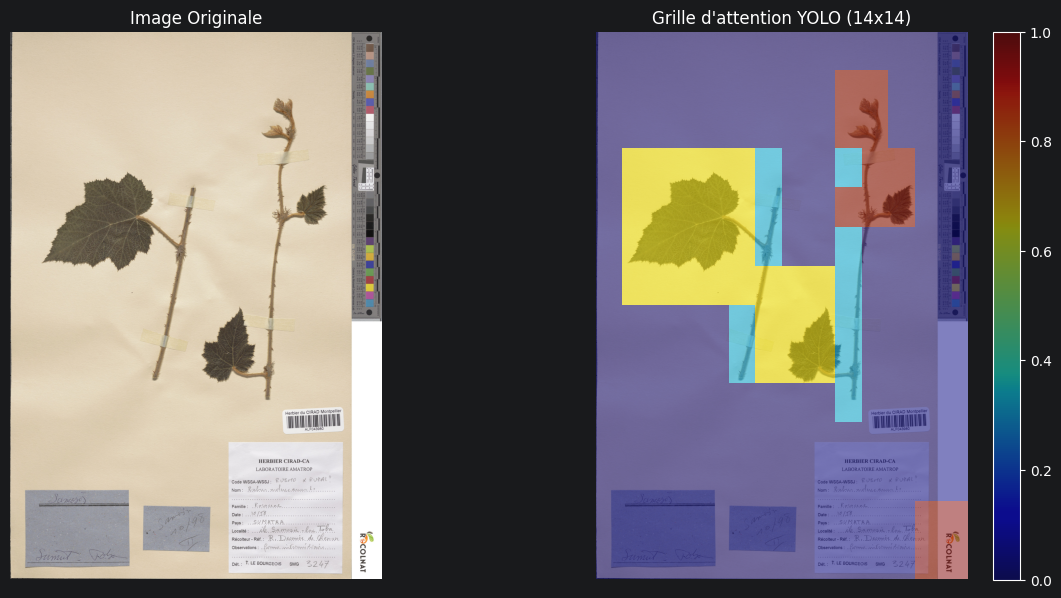

In [28]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np


def visualiser_patchs_yolo(chemin_image, chemin_pt, grid_size=14):
    """
    Superpose la grille d'attention YOLO (.pt) sur l'image originale.
    """

    img = Image.open(chemin_image).convert('RGB')

    weights = torch.load(chemin_pt)

    grille_2d = weights.view(grid_size, grid_size).cpu().numpy()

    grille_norm = (grille_2d - grille_2d.min()) / (grille_2d.max() - grille_2d.min() + 1e-8)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(img)
    axes[0].set_title("Image Originale")
    axes[0].axis('off')

    axes[1].imshow(img)

    heatmap = axes[1].imshow(grille_norm, cmap='jet', alpha=0.5, extent=[0, img.width, img.height, 0])
    axes[1].set_title(f"Grille d'attention YOLO ({grid_size}x{grid_size})")
    axes[1].axis('off')

    plt.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


IMAGE_TEST = "/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data/train/original/epines/ALF043980.jpg"
PT_TEST = "/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data/train/original/epines/ALF043980_weights.pt"

visualiser_patchs_yolo(IMAGE_TEST, PT_TEST)

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

# --- 1. SETUP DU MATÉRIEL ET DU MODÈLE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entraînement sur : {device}")

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-4)

EPOCHS = 2

print("Début de l'entraînement...")

for epoch in range(EPOCHS):
    model.train()
    loss_totale = 0.0

    for batch_idx, (img_orig, img_seg, labels, weights) in enumerate(data_loader_train):
        img_orig = img_orig.to(device)
        img_seg = img_seg.to(device)
        labels = labels.to(device)
        weights = weights.to(device)

        optimizer.zero_grad()

        weights = weights.view(weights.shape[0], -1, 1)
        predictions = model(img_orig, img_seg, weights)

        loss = criterion(predictions, labels)

        loss.backward()

        optimizer.step()

        loss_totale += loss.item()
        print(f"Epoch [{epoch + 1}/{EPOCHS}] - Batch {batch_idx + 1} | Loss: {loss.item():.4f}")

    loss_moyenne = loss_totale / len(data_loader_train)
    print(f"--- Fin Epoch {epoch + 1} | Loss Moyenne: {loss_moyenne:.4f} ---\n")

Entraînement sur : cpu
🚀 Début de l'entraînement...
Epoch [1/2] - Batch 1 | Loss: 0.6757
--- Fin Epoch 1 | Loss Moyenne: 0.6757 ---

Epoch [2/2] - Batch 1 | Loss: 0.5597
--- Fin Epoch 2 | Loss Moyenne: 0.5597 ---



In [1]:
import torch

# Remplace par le chemin d'un de tes fichiers générés
path = "/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data/train/original/epines/ALF043980_weights.pt"
weights = torch.load(path)

print(f"Format du tenseur : {weights.shape}")
print(f"Valeur Max : {weights.max().item()}")
print(f"Valeur Min : {weights.min().item()}")
print(f"Moyenne : {weights.mean().item()}")
print("Contenu (grille) :")
print(weights.view(14, 14)) # On le remet en carré pour mieux voir

Format du tenseur : torch.Size([1, 196, 1])
Valeur Max : 3.0
Valeur Min : 0.10000000149011612
Moyenne : 0.6239795684814453
Contenu (grille) :
tensor([[0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
         0.1000, 0.1000, 0.1000, 0.1000, 0.1000],
        [0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
         3.0000, 3.0000, 0.1000, 0.1000, 0.1000],
        [0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
         3.0000, 3.0000, 0.1000, 0.1000, 0.1000],
        [0.1000, 2.0000, 2.0000, 2.0000, 2.0000, 2.0000, 1.0000, 0.1000, 0.1000,
         1.0000, 3.0000, 3.0000, 0.1000, 0.1000],
        [0.1000, 2.0000, 2.0000, 2.0000, 2.0000, 2.0000, 1.0000, 0.1000, 0.1000,
         3.0000, 3.0000, 3.0000, 0.1000, 0.1000],
        [0.1000, 2.0000, 2.0000, 2.0000, 2.0000, 2.0000, 1.0000, 0.1000, 0.1000,
         1.0000, 0.1000, 0.1000, 0.1000, 0.1000],
        [0.1000, 2.0000, 2.0000, 2.0000, 2.0000, 2.0000, 2.0000, 2.0000,

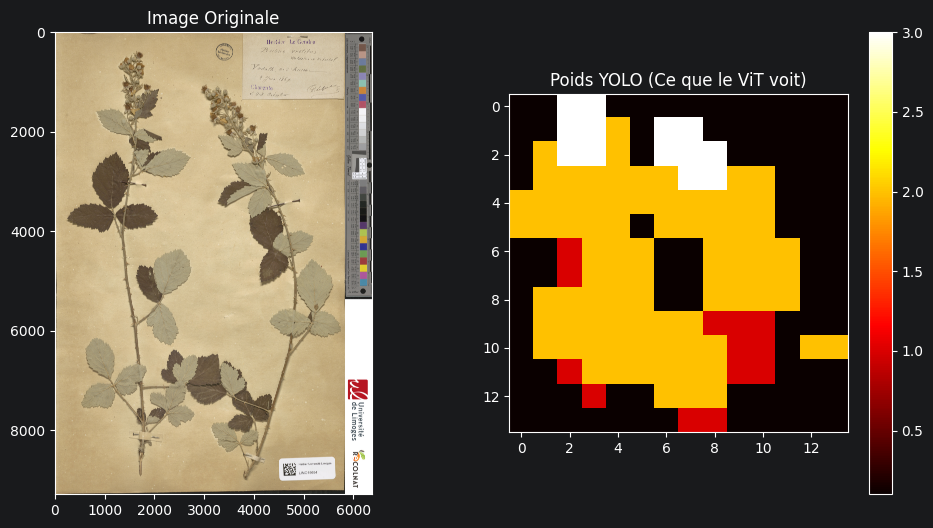

In [5]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def plot_yolo_weights(img_path, pt_path):
    # Charger l'image et le tenseur
    img = Image.open(img_path)
    weights = torch.load(pt_path) # Supposé (196, 1) ou (14, 14)

    # Remettre les poids en grille 14x14
    grid_w = weights.view(14, 14).numpy()

    # Affichage
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(img)
    ax[0].set_title("Image Originale")

    # On affiche la Heatmap des poids
    im = ax[1].imshow(grid_w, cmap='hot', interpolation='nearest')
    plt.colorbar(im, ax=ax[1])
    ax[1].set_title("Poids YOLO (Ce que le ViT voit)")

    plt.show()

# Exemple d'utilisation
plot_yolo_weights("/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data/train/original/epines/LIMO15654.jpg", "/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data/train/original/epines/LIMO15654_weights.pt")

In [6]:
import torch
import os
from pathlib import Path
import random

def check_pt_files(root_dir, num_samples=3):
    root = Path(root_dir)
    # On cherche tous les fichiers qui finissent par _weights.pt
    pt_files = list(root.rglob("*_weights.pt"))

    if not pt_files:
        print(f"?? Aucun fichier .pt trouvé dans {root_dir}")
        return

    print(f"?? Trouvé {len(pt_files)} fichiers .pt au total.")
    print("-" * 50)

    # On en prend quelques-uns au hasard pour vérifier
    samples = random.sample(pt_files, min(num_samples, len(pt_files)))

    for pt_path in samples:
        print(f"\n?? Analyse de : {pt_path.name}")
        try:
            data = torch.load(pt_path)

            # 1. Vérification de la Heatmap
            if 'global_heatmap' in data:
                heatmap = data['global_heatmap']
                print(f"   ? Heatmap globale : Shape {heatmap.shape} (OK)")
            else:
                print("   ?? ERREUR : 'global_heatmap' manquante !")

            # 2. Vérification des Patchs
            if 'patches' in data:
                patches = data['patches']
                num_patches = len(patches)
                print(f"   ? Nombre de patchs : {num_patches}")

                if num_patches > 0:
                    # On vérifie la taille du premier patch
                    p1 = patches[0]
                    print(f"   ? Taille du patch 0 : {p1.shape} (Attendu: [3, 224, 224])")

                    if p1.max() > 1.0:
                        print("   ?? ATTENTION : Les pixels ne sont pas normalisés (max > 1)")
            else:
                print("   ?? ERREUR : 'patches' manquants !")

        except Exception as e:
            print(f"   ?? Impossible de lire le fichier : {e}")


# Change le chemin par ton dossier de données
DATA_PATH = "/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data/"
check_pt_files(DATA_PATH)

?? Trouvé 4 fichiers .pt au total.
--------------------------------------------------

?? Analyse de : BAIL013296_weights.pt
   ? Heatmap globale : Shape torch.Size([1, 7, 64, 64]) (OK)
   ? Nombre de patchs : 86
   ? Taille du patch 0 : torch.Size([3, 224, 224]) (Attendu: [3, 224, 224])

?? Analyse de : ALF043980_weights.pt
   ? Heatmap globale : Shape torch.Size([1, 7, 64, 64]) (OK)
   ? Nombre de patchs : 11
   ? Taille du patch 0 : torch.Size([3, 224, 224]) (Attendu: [3, 224, 224])

?? Analyse de : ALF044006_weights.pt
   ? Heatmap globale : Shape torch.Size([1, 7, 64, 64]) (OK)
   ? Nombre de patchs : 39
   ? Taille du patch 0 : torch.Size([3, 224, 224]) (Attendu: [3, 224, 224])


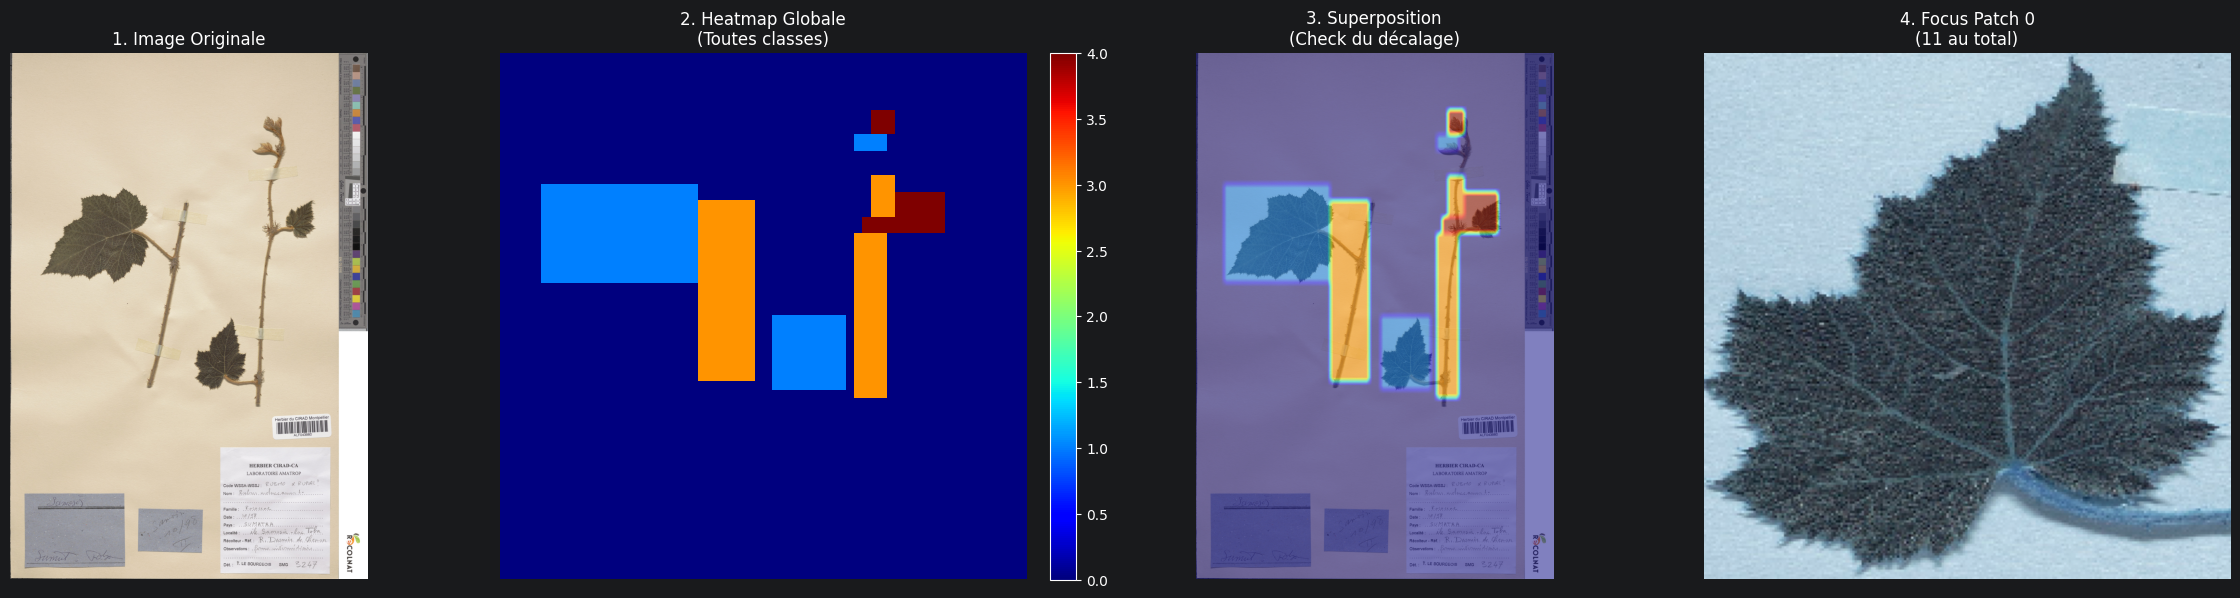


--- Analyse détaillée par Organe ---


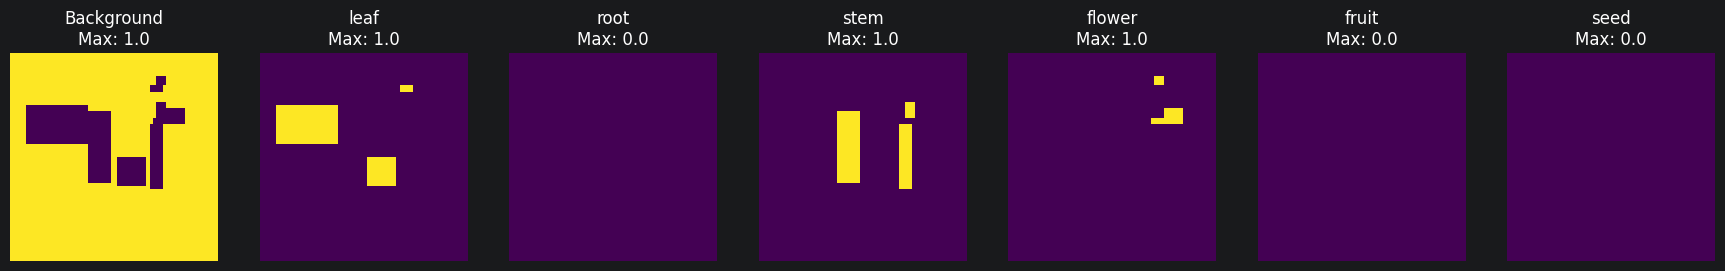

In [25]:
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def visualize_sample(image_path, pt_path):
    # 1. Charger l'image originale
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        print(f"Erreur : Impossible de lire l'image {image_path}")
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2. Charger le fichier .pt
    data = torch.load(pt_path)
    heatmap = data['global_heatmap']  # Shape [1, 7, 64, 64]
    patches = data['patches']         # Liste de tenseurs [3, 224, 224]

    # Noms des classes d'après ton YAML
    class_names_yolo = ["leaf", "root", "stem", "flower", "fruit", "seed"]
    # Couleurs pour les Bounding Boxes (RGB)
    colors = [(0, 255, 0), (128, 128, 0), (255, 0, 0), (255, 255, 0), (255, 165, 0), (128, 0, 128)]

    # --- ÉTAPE : DESSINER LES BOUNDING BOXES ---
    # Comme on n'a plus les coordonnées brutes dans le .pt final,
    # on va les "deviner" à partir de la heatmap pour la visualisation
    img_bbox = img_rgb.copy()
    h, w, _ = img_bbox.shape

    # --- AFFICHAGE PRINCIPAL (4 colonnes désormais) ---
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    # A. Image avec Bounding Boxes (Reconstruites depuis la heatmap pour vérification)
    # Note : On affiche l'image originale pour le contexte
    axes[0].imshow(img_rgb)
    axes[0].set_title("1. Image Originale")
    axes[0].axis('off')

    # B. Heatmap Globale
    weighted_map = torch.zeros((64, 64))
    for i in range(1, 7):
        weighted_map += heatmap[0, i, :, :] * i
    combined_map = weighted_map.numpy()
    im_heat = axes[1].imshow(combined_map, cmap='jet')
    axes[1].set_title(f"2. Heatmap Globale\n(Toutes classes)")
    plt.colorbar(im_heat, ax=axes[1], fraction=0.046, pad=0.04)
    axes[1].axis('off')

    # C. Image BBox (Simulation de ce que YOLO a envoyé à la heatmap)
    # On superpose la heatmap en transparence sur l'originale pour voir le "fit"
    axes[2].imshow(img_rgb)
    # On redimensionne la heatmap à la taille de l'image pour la superposition
    heat_resized = cv2.resize(combined_map, (w, h))
    axes[2].imshow(heat_resized, alpha=0.5, cmap='jet')
    axes[2].set_title("3. Superposition\n(Check du décalage)")
    axes[2].axis('off')

    # D. Zoom sur le Premier Patch
    if len(patches) > 0:
        p0 = patches[0].permute(1, 2, 0).numpy()
        axes[3].imshow(p0)
        axes[3].set_title(f"4. Focus Patch 0\n({len(patches)} au total)")
    else:
        axes[3].text(0.5, 0.5, "Aucun patch", ha='center')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    # --- DÉTAIL PAR ORGANE ---
    print(f"\n--- Analyse détaillée par Organe ---")
    num_channels = heatmap.shape[1]
    fig2, axes2 = plt.subplots(1, num_channels, figsize=(22, 4))

    full_names = ["Background"] + class_names_yolo

    for i in range(num_channels):
        channel_data = heatmap[0, i, :, :].numpy()
        axes2[i].imshow(channel_data, cmap='viridis', vmin=0, vmax=1)
        axes2[i].set_title(f"{full_names[i]}\nMax: {channel_data.max():.1f}")
        axes2[i].axis('off')

    plt.show()

# --- CONFIGURATION ---
IMG_FILE = Path("/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data/train/original/epines/ALF043980.jpg")
PT_FILE = IMG_FILE.parent / f"{IMG_FILE.stem}_weights.pt"

if IMG_FILE.exists() and PT_FILE.exists():
    visualize_sample(IMG_FILE, PT_FILE)
else:
    print("Fichiers introuvables !")

AttributeError: 'dict' object has no attribute 'permute'

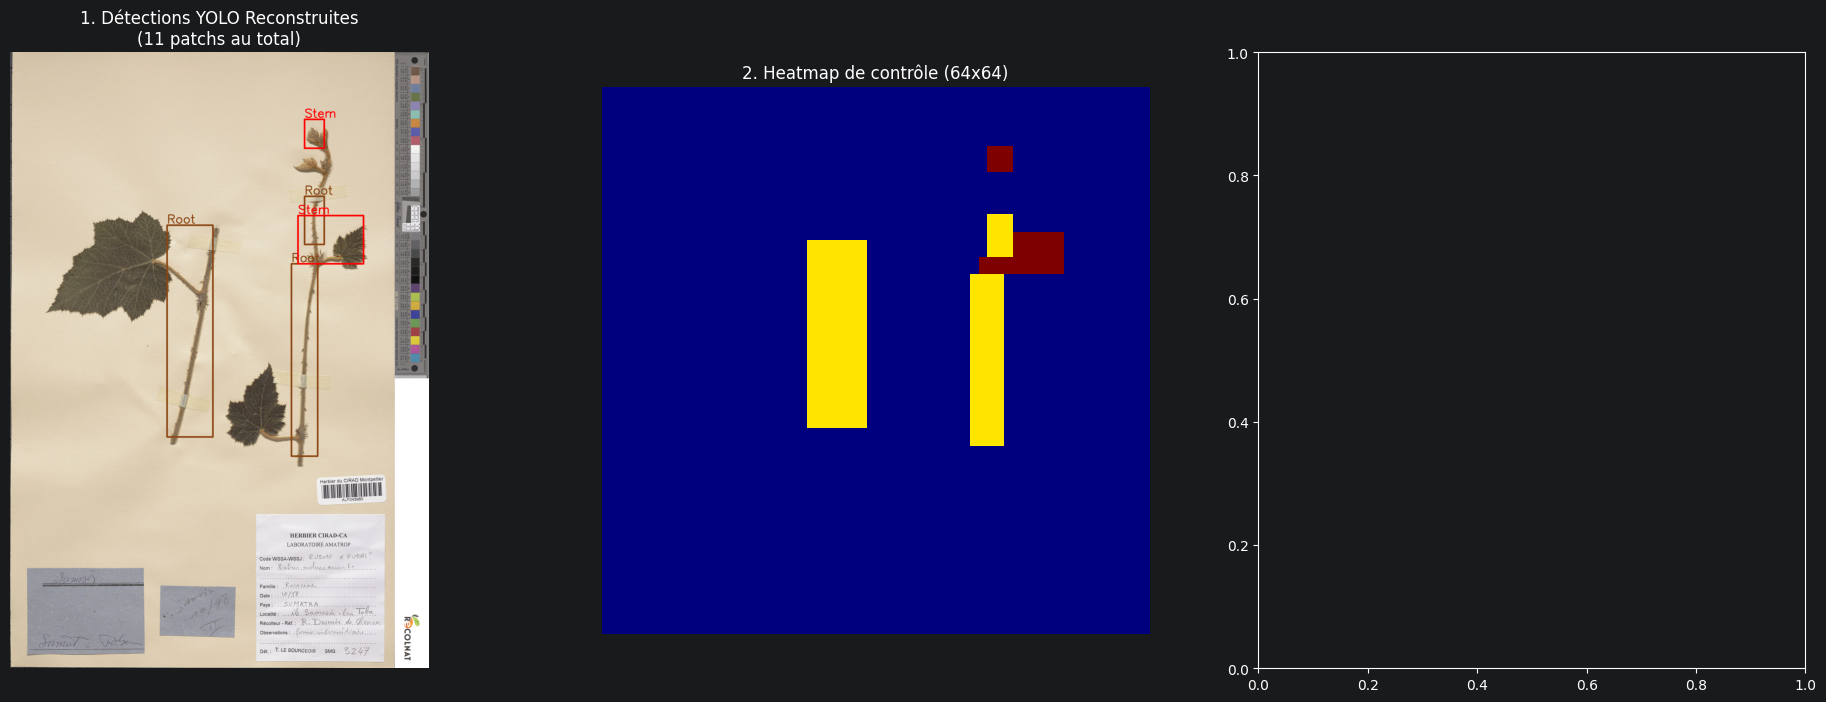

In [33]:
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def visualize_with_boxes(image_path, pt_path):
    # 1. Charger l'image originale
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        print(f"Erreur : Impossible de lire l'image {image_path}")
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape

    # 2. Charger le fichier .pt
    data = torch.load(pt_path)
    heatmap = data['global_heatmap']  # Shape [1, 7, 64, 64]
    patches = data['patches']         # Liste de tenseurs [3, 224, 224]

    # Noms des classes d'après ton YAML
    # Rappel : Index 0 = Background, 1 = Leaf, 2 = Root, 3 = Stem, 4 = Flower, 5 = Fruit, 6 = Seed
    class_names = ["Background", "Leaf", "Root", "Stem", "Flower", "Fruit", "Seed"]
    # Couleurs distinctes pour chaque classe (RGB)
    colors = [
        (255, 255, 255), (0, 255, 0), (139, 69, 19),
        (255, 0, 0), (255, 255, 0), (255, 165, 0), (128, 0, 128)
    ]

    # --- CRÉATION DE L'IMAGE AVEC BOUNDING BOXES ---
    img_with_boxes = img_rgb.copy()
    grid_size = heatmap.shape[2] # 64

    # On parcourt chaque canal d'organe (de 1 à 6)
    for c_idx in range(1, 6):
        channel = heatmap[0, c_idx].numpy()
        # On trouve les zones où la heatmap vaut 1.0 (ou > 0.5)
        # On utilise OpenCV pour trouver les contours de ces rectangles
        mask = (channel > 0.5).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            # Récupérer le rectangle englobant dans la grille 64x64
            gx, gy, gw, gh = cv2.boundingRect(cnt)

            # Convertir les coordonnées 64x64 vers la taille réelle de l'image
            x1 = int((gx / grid_size) * w)
            y1 = int((gy / grid_size) * h)
            x2 = int(((gx + gw) / grid_size) * w)
            y2 = int(((gy + gh) / grid_size) * h)

            # Dessiner le rectangle
            color = colors[c_idx]
            cv2.rectangle(img_with_boxes, (x1, y1), (x2, y2), color, 15) # Trait épais (15px)

            # Ajouter le nom de la classe
            label = class_names[c_idx]
            cv2.putText(img_with_boxes, label, (x1, y1 - 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 4, color, 10)

    # --- AFFICHAGE ---
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # A. Image avec Bounding Boxes reconstruites
    axes[0].imshow(img_with_boxes)
    axes[0].set_title(f"1. Détections YOLO Reconstruites\n({len(patches)} patchs au total)")
    axes[0].axis('off')

    # B. Heatmap Globale pour comparer
    weighted_map = torch.zeros((64, 64))
    for i in range(1, 6):
        weighted_map += heatmap[0, i, :, :] * i
    combined_map = weighted_map.numpy()
    axes[1].imshow(combined_map, cmap='jet')
    axes[1].set_title("2. Heatmap de contrôle (64x64)")
    axes[1].axis('off')

    # C. Premier Patch (Le zoom réel)
    if len(patches) > 0:
        p0 = patches[0].permute(1, 2, 0).numpy()
        axes[2].imshow(p0)
        axes[2].set_title(f"3. Zoom Patch 0\n(Vérification qualité)")
    else:
        axes[2].text(0.5, 0.5, "Aucun patch", ha='center')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # --- LOG DES CLASSES TROUVÉES ---
    print("\n--- Bilan des détections présentes dans le fichier .pt ---")
    for i in range(1, 7):
        if heatmap[0, i].max() > 0:
            print(f"[OK] Classe '{class_names[i]}' détectée.")
        else:
            print(f"[ABSENT] Classe '{class_names[i]}' non trouvée.")

# --- CONFIGURATION ---
IMG_FILE = Path("/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data/train/original/epines/ALF043980.jpg")
PT_FILE = IMG_FILE.parent / f"{IMG_FILE.stem}_weights.pt"

if IMG_FILE.exists() and PT_FILE.exists():
    visualize_with_boxes(IMG_FILE, PT_FILE)
else:
    print("Fichiers introuvables !")

In [27]:
import torch
from pathlib import Path
from tqdm import tqdm
import numpy as np

def analyze_dataset_quality(base_path, max_threshold=50):
    base = Path(base_path)
    subsets = [
        "train/original/epines",
        "train/original/no_epines",
        "val/original/epines",
        "val/original/no_epines"
    ]

    # Noms des classes selon ton YAML
    # Rappel : 0=Fond, 1=Leaf, 2=Root, 3=Stem, 4=Flower, 5=Fruit, 6=Seed
    class_names = ["Leaf", "Root", "Stem", "Flower", "Fruit", "Seed"]

    print(f"\n{'Sous-dossier':<15} | {'Img':<4} | {'Avg':<4} | {'0 Pat.':<6} | {'>50':<4} | {'Stats Classes (Total détecté)'}")
    print("-" * 110)

    for sub in subsets:
        folder = base / sub
        pt_files = list(folder.glob("*_weights.pt"))
        if not pt_files: continue

        count_zero = 0
        count_too_many = 0
        all_counts = []
        # Dictionnaire pour compter le total par classe dans tout le dossier
        class_totals = {name: 0 for name in class_names}

        for pt_path in tqdm(pt_files, desc=f"Scan {sub.split('/')[-1]}", leave=False):
            try:
                data = torch.load(pt_path)
                heatmap = data.get('global_heatmap') # Shape [1, 7, 64, 64]
                n = len(data.get('patches', []))
                all_counts.append(n)

                if n == 0: count_zero += 1
                if n > max_threshold: count_too_many += 1

                # On compte le nombre d'organes par canal (on cherche les blocs de 1.0)
                # Note: Ce calcul est une estimation basée sur la heatmap
                for i, name in enumerate(class_names):
                    # i+1 car le canal 0 est le fond
                    canal = heatmap[0, i+1].numpy()
                    if canal.max() > 0:
                        # On compte "1" si la classe est présente sur l'image
                        class_totals[name] += 1

            except Exception:
                continue

        if all_counts:
            avg = sum(all_counts) / len(all_counts)
            # On prépare la chaîne de stats (ex: L:300, S:150...)
            # L=Leaf, R=Root, S=Stem, Fl=Flower, Fr=Fruit, Se=Seed
            stats_str = f"L:{class_totals['Leaf']} | S:{class_totals['Stem']} | Fl:{class_totals['Flower']} | R:{class_totals['Root']}"

            name_folder = sub.replace("/original/", " ").split("/")[-1]
            print(f"{name_folder:<15} | {len(all_counts):<4} | {avg:<4.1f} | {count_zero:<6} | {count_too_many:<4} | {stats_str}")

if __name__ == "__main__":
    DATA_ROOT = "/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data/"
    analyze_dataset_quality(DATA_ROOT)


Sous-dossier    | Img  | Avg  | 0 Pat. | >50  | Stats Classes (Total détecté)
--------------------------------------------------------------------------------------------------------------


train epines    | 389  | 33.4 | 0      | 48   | L:389 | S:388 | Fl:354 | R:18


train no_epines | 321  | 35.2 | 0      | 72   | L:321 | S:319 | Fl:248 | R:21


val epines      | 102  | 34.0 | 0      | 13   | L:102 | S:101 | Fl:93 | R:3


val no_epines   | 86   | 38.1 | 0      | 21   | L:86 | S:86 | Fl:66 | R:6


In [29]:
import torch
# Charge un de tes fichiers .pt
data = torch.load("/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data/train/original/epines/ALF046447_weights.pt")
print(data.keys())

dict_keys(['global_heatmap', 'patches'])


In [30]:
import torch
data = torch.load("/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data/train/original/epines/ALF046447_weights.pt")
print(data['global_heatmap'].shape)

torch.Size([1, 6, 64, 64])
